### Task 1: Dataset Generation and Preprocessing 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

Dataset Shape: (1000, 2)
Labels Shape: (1000,)
Class distribution: Class 0: 500, Class 1: 500


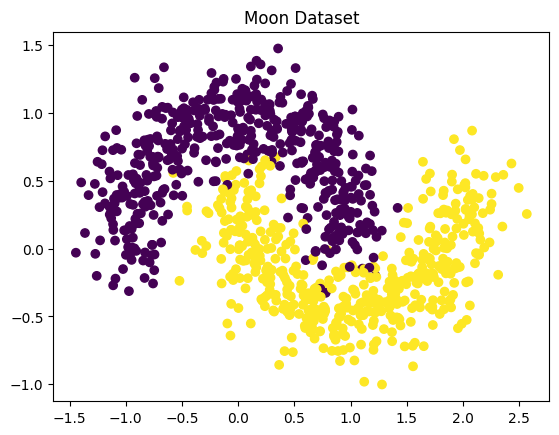

In [13]:
X,y=make_moons(n_samples=1000,noise=0.2,random_state=42)

print("Dataset Shape:",X.shape)
print("Labels Shape:",y.shape)
print(f"Class distribution: Class 0: {np.sum(y==0)}, Class 1: {np.sum(y==1)}")

plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.title("Moon Dataset")
plt.show()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Stanscaler=StandardScaler()
X_stanscaled_train=Stanscaler.fit_transform(X_train)
X_stanscaled_test=Stanscaler.transform(X_test)

### Task 2: Two-Layer Neural Network

In [14]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_grad(z):
    s=sigmoid(z)
    return s*(1-s)

def tanh(z):
    return np.tanh(z)

def tanh_grad(z):
    return 1-tanh(z)**2

def relu(z):
    return np.maximum(0,z)

def relu_grad(z):
    return (z>0).astype(float)
    

In [49]:
class TwoLayerNN:
    def __init__(self, input_size, hidden_size, output_size,activation, activation_grad):
        
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        self.activation = activation
        self.activation_grad = activation_grad
        self.gradient_norms = []

    def forward(self, X):
        self.X = X

        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.activation(self.Z1)

        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)

        return self.A2

    def compute_loss(self, y, y_pred):
        epsilon = 1e-8
        loss = -np.mean(y*np.log(y_pred+epsilon)+(1-y)*np.log(1-y_pred+epsilon))
        return loss
    
    def backward(self, y):
        m = y.shape[0]
        y = y.reshape(-1,1)

        dZ2 = self.A2 - y
        dW2 = (self.A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True)/m

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.activation_grad(self.Z1)

        dW1 = (self.X.T @ dZ1)/m
        db1 = np.sum(dZ1, axis=0, keepdims=True)/m

        grad_norm = np.linalg.norm(dW1) + np.linalg.norm(dW2)
        self.gradient_norms.append(grad_norm)

        return dW1, db1, dW2, db2

    def update(self, dW1, db1, dW2, db2, lr):
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        
    def train(self, X, y, epochs, lr):

        losses = []
        for epoch in range(epochs):

            y_pred = self.forward(X)
            loss = self.compute_loss(y.reshape(-1,1), y_pred)

            dW1, db1, dW2, db2 = self.backward(y)
            self.update(dW1, db1, dW2, db2, lr)

            losses.append(loss)

            if (epoch+1) % 100 == 0:
                print(f"Epoch {epoch+1} Loss: {loss:.4f}")

        return losses


Epoch 100 Loss: 0.6930
Epoch 200 Loss: 0.6927
Epoch 300 Loss: 0.6918
Epoch 400 Loss: 0.6888
Epoch 500 Loss: 0.6800
Epoch 600 Loss: 0.6558
Epoch 700 Loss: 0.6015
Epoch 800 Loss: 0.5183
Epoch 900 Loss: 0.4374
Epoch 1000 Loss: 0.3810
Epoch 100 Loss: 0.6670
Epoch 200 Loss: 0.3948
Epoch 300 Loss: 0.3086
Epoch 400 Loss: 0.2964
Epoch 500 Loss: 0.2937
Epoch 600 Loss: 0.2929
Epoch 700 Loss: 0.2925
Epoch 800 Loss: 0.2922
Epoch 900 Loss: 0.2919
Epoch 1000 Loss: 0.2917
Epoch 100 Loss: 0.6905
Epoch 200 Loss: 0.6514
Epoch 300 Loss: 0.4494
Epoch 400 Loss: 0.3233
Epoch 500 Loss: 0.3013
Epoch 600 Loss: 0.2969
Epoch 700 Loss: 0.2951
Epoch 800 Loss: 0.2935
Epoch 900 Loss: 0.2924
Epoch 1000 Loss: 0.2914


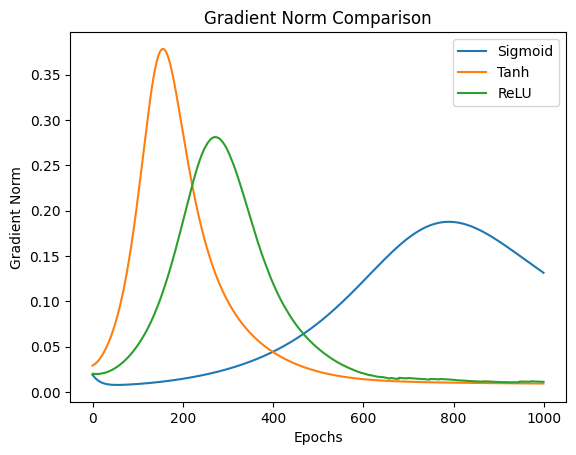

In [50]:
input_size = 2
hidden_size = 10
output_size = 1
epochs = 1000
lr = 0.05

model_sigmoid = TwoLayerNN(input_size, hidden_size, output_size,sigmoid,sigmoid_grad)
loss_sigmoid = model_sigmoid.train(X_stanscaled_train, y_train, epochs, lr)

model_tanh = TwoLayerNN(input_size, hidden_size, output_size,tanh,tanh_grad)
loss_tanh = model_tanh.train(X_stanscaled_train, y_train, epochs, lr)

model_relu = TwoLayerNN(input_size, hidden_size, output_size,relu, relu_grad)
loss_relu = model_relu.train(X_stanscaled_train, y_train, epochs, lr)

plt.plot(model_sigmoid.gradient_norms, label="Sigmoid")
plt.plot(model_tanh.gradient_norms, label="Tanh")
plt.plot(model_relu.gradient_norms, label="ReLU")

plt.xlabel("Epochs")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm Comparison")
plt.legend()
plt.show()

### Task 3: Deep Neural Networks with  (5+ Layers)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim


X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1,1)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1,1)

In [18]:
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, activation):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(activation)

        for _ in range(num_layers-1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation)

        self.hidden = nn.Sequential(*layers)

        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden(x)
        x = torch.sigmoid(self.output(x)) 
        return x


In [19]:
def train_model(model, X_train, y_train, epochs, lr):

    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    total_grad_norms = []
    losses = []
    layer_grad_norms = {}

    for epoch in range(epochs):
        
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        total_norm = 0
        
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()
                total_norm += grad_norm ** 2
                if "weight" in name:

                    if name not in layer_grad_norms:
                        layer_grad_norms[name] = []

                    layer_grad_norms[name].append(grad_norm)

        total_norm = total_norm ** 0.5
        total_grad_norms.append(total_norm)

        optimizer.step()
        losses.append(loss.item())

        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    return losses, total_grad_norms, layer_grad_norms


In [20]:
input_size = 2
hidden_size = 20
output_size = 1
epochs = 1000
lr = 0.01

depths = [5,10,15]
activations = {
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh(),
    "relu": nn.ReLU()
}

results = {}

for depth in depths:
    results[depth] = {}
    for name, act in activations.items():
        print(f"\nTraining Depth={depth}, Activation={name}")
        model = DeepNN(input_size, hidden_size, output_size, depth, act)
        losses, total_grads, layer_grads = train_model(model,X_train_tensor,y_train_tensor,epochs,lr)
        
        results[depth][name] = {
            "loss": losses,
            "total_grad": total_grads,
            "layer_grad": layer_grads
        }



Training Depth=5, Activation=sigmoid
Epoch 100, Loss: 0.6948
Epoch 200, Loss: 0.6932
Epoch 300, Loss: 0.6931
Epoch 400, Loss: 0.6931
Epoch 500, Loss: 0.6931
Epoch 600, Loss: 0.6931
Epoch 700, Loss: 0.6931
Epoch 800, Loss: 0.6931
Epoch 900, Loss: 0.6931
Epoch 1000, Loss: 0.6931

Training Depth=5, Activation=tanh
Epoch 100, Loss: 0.6909
Epoch 200, Loss: 0.6832
Epoch 300, Loss: 0.6721
Epoch 400, Loss: 0.6513
Epoch 500, Loss: 0.6071
Epoch 600, Loss: 0.5202
Epoch 700, Loss: 0.4219
Epoch 800, Loss: 0.3632
Epoch 900, Loss: 0.3319
Epoch 1000, Loss: 0.3155

Training Depth=5, Activation=relu
Epoch 100, Loss: 0.6921
Epoch 200, Loss: 0.6914
Epoch 300, Loss: 0.6907
Epoch 400, Loss: 0.6900
Epoch 500, Loss: 0.6893
Epoch 600, Loss: 0.6885
Epoch 700, Loss: 0.6875
Epoch 800, Loss: 0.6862
Epoch 900, Loss: 0.6845
Epoch 1000, Loss: 0.6822

Training Depth=10, Activation=sigmoid
Epoch 100, Loss: 0.6937
Epoch 200, Loss: 0.6932
Epoch 300, Loss: 0.6931
Epoch 400, Loss: 0.6931
Epoch 500, Loss: 0.6931
Epoch 600,

### Task-4: Gradient Monitoring and Analysis

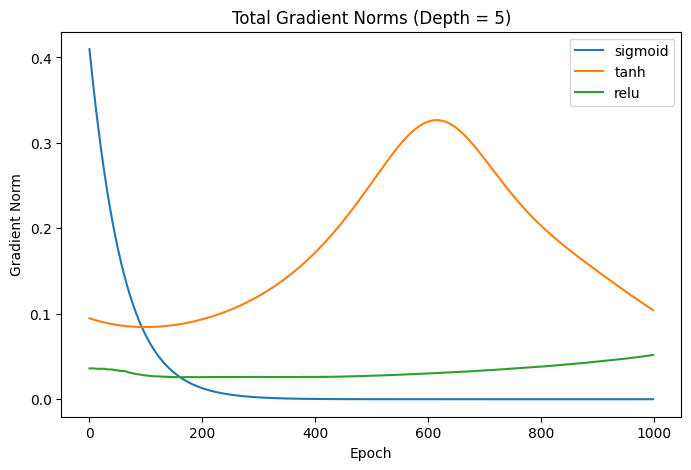

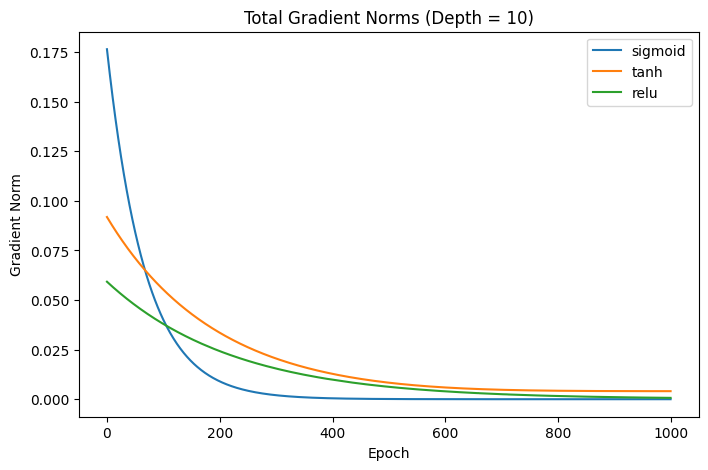

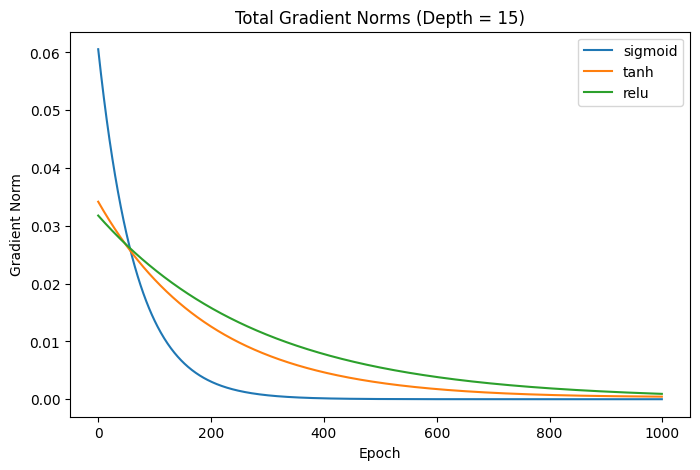

In [21]:
for depth in depths:

    plt.figure(figsize=(8,5))

    for act in activations.keys():
        plt.plot(results[depth][act]["total_grad"], label=act)

    plt.title(f"Total Gradient Norms (Depth = {depth})")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.show()


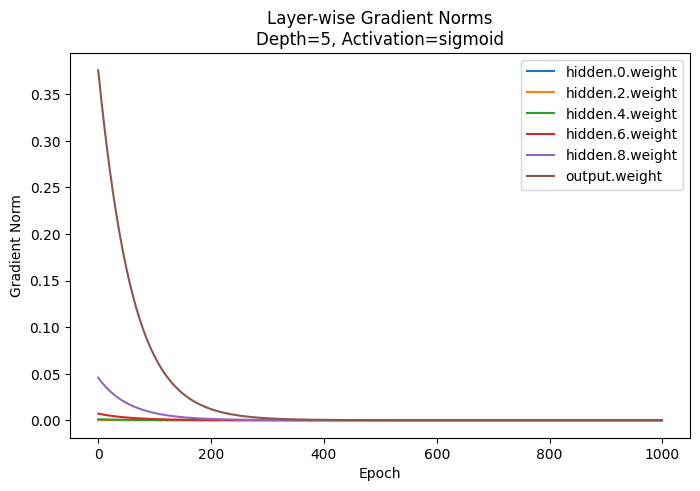

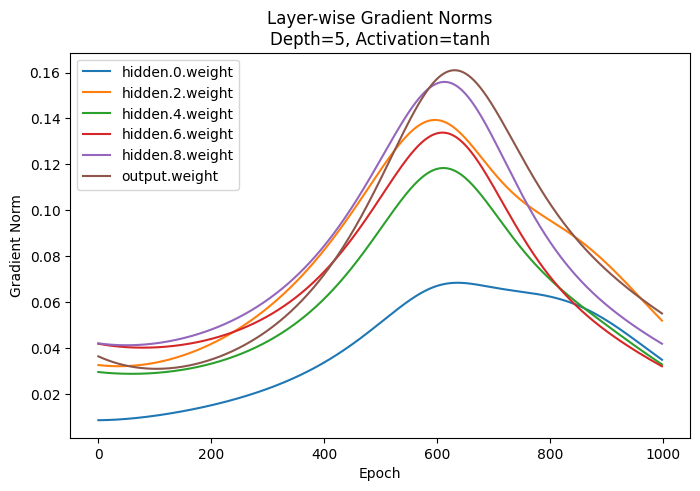

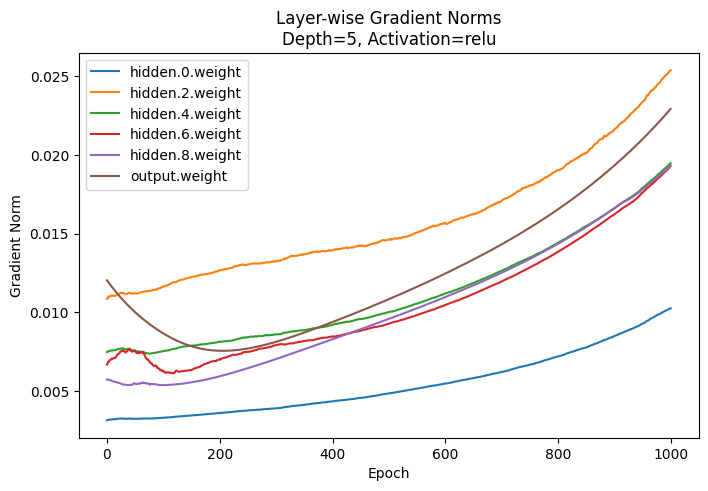

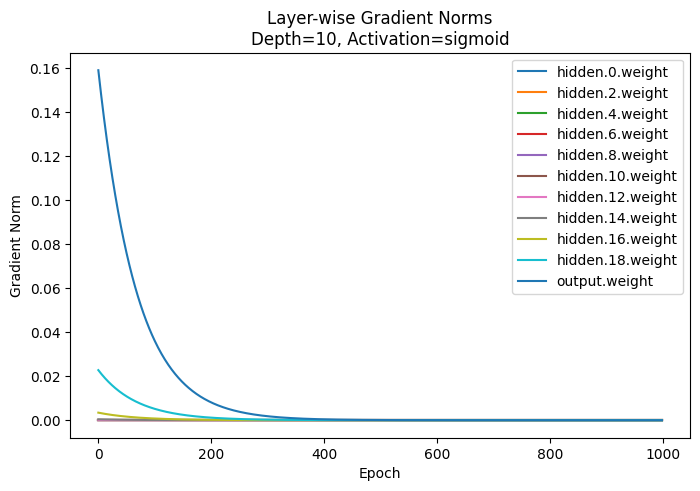

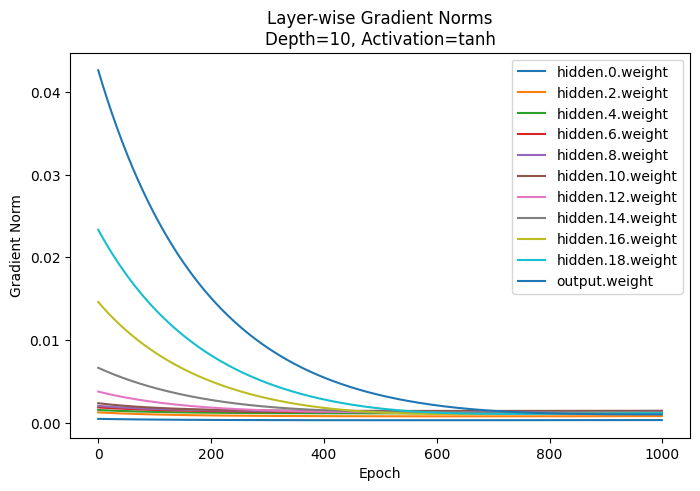

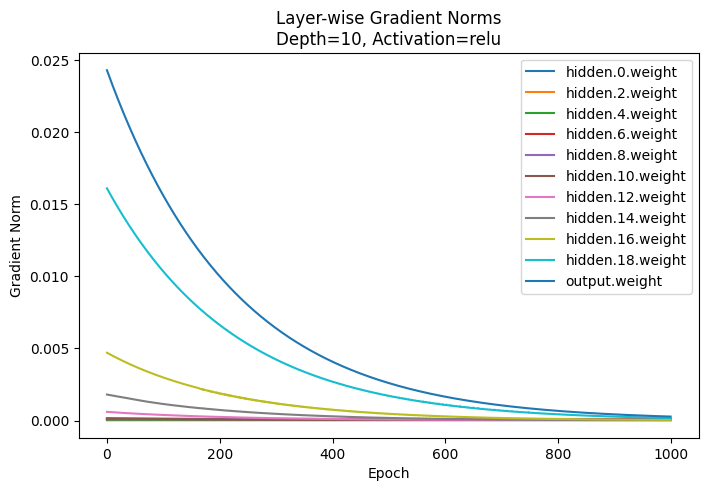

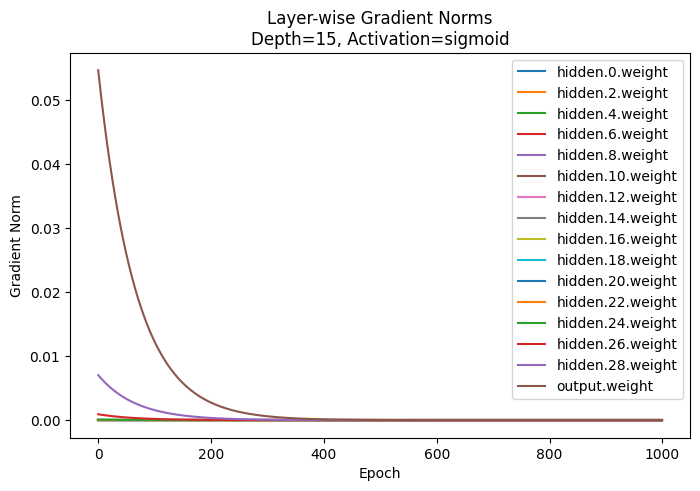

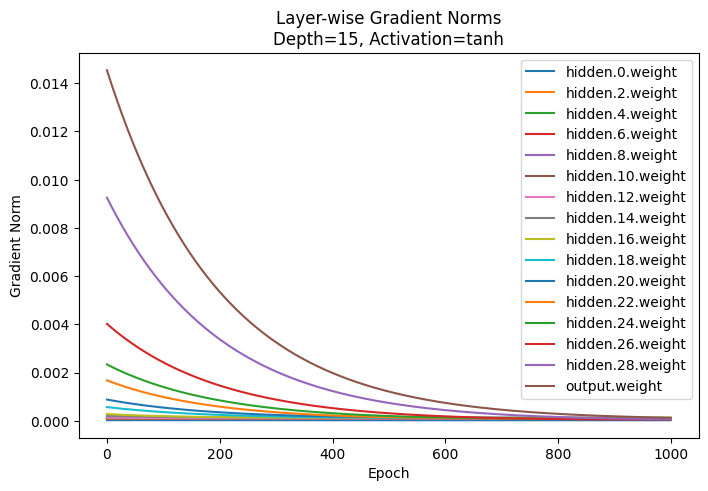

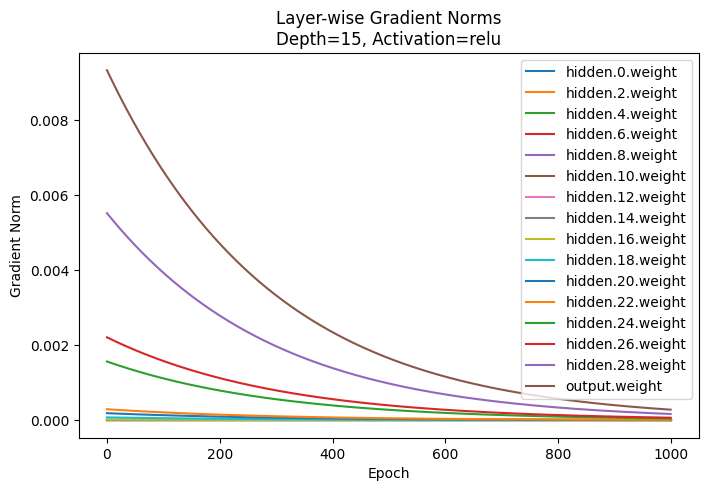

In [22]:
for depth in depths:
    for act in activations.keys():

        grads = results[depth][act]["layer_grad"]

        plt.figure(figsize=(8,5))

        for layer_name, values in grads.items():
            plt.plot(values, label=layer_name)

        plt.title(f"Layer-wise Gradient Norms\nDepth={depth}, Activation={act}")
        plt.xlabel("Epoch")
        plt.ylabel("Gradient Norm")
        plt.legend()
        plt.show()
